In [1]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.auto import tqdm
from google.oauth2 import service_account
import numpy as np

# 1. 신분증(JSON 키) 경로 지정
KEY_PATH = '../google_key.json'

# 2. 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)

# 3. 프로젝트 ID 설정
project_id = 'gdelt-analysis-494301'

# 4. 데이터 불러오기
query = "SELECT SQLDATE FROM `gdelt-bq.full.events` LIMIT 5"
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("인증 성공! 데이터를 가져왔습니다.")

Downloading: 100%|██████████|
인증 성공! 데이터를 가져왔습니다.


In [2]:
# 1. 고위험군 CAMEO 코드 리스트
target_cameo_codes = [
    '150', '151', '152', '153', '154', '155', 
    '190', '191', '192', '193', '194', '195', '196', 
    '200', '201', '202', '203', '204'
]
formatted_codes = ", ".join([f"'{code}'" for code in target_cameo_codes])

query = f"""
SELECT 
    SQLDATE, 
    EventCode,
    GoldsteinScale, 
    NumMentions, 
    AvgTone,
    ActionGeo_Type,
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401 
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})
  AND IsRootEvent = 1                 -- 핵심 사건만 필터링
  AND ActionGeo_Type IN (3, 4, 5)
"""

# 2. 데이터 불러오기
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("데이터 불러오기 완료")
display(df.head())

Downloading: 100%|██████████|
데이터 불러오기 완료


,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20230121,192,-9.5,10,-0.840336,4,39.9289,116.388,https://www.shanghaisun.com/news/273404777/tai...
1,20221016,150,-7.2,5,-2.020202,4,39.9289,116.388,https://asia.nikkei.com/Politics/China-s-party...
2,20221016,192,-9.5,2,2.376238,4,25.0478,121.532,https://www.assahifa.com/english/world/chinese...
3,20221016,192,-9.5,6,2.376238,4,25.0478,121.532,https://www.assahifa.com/english/world/chinese...
4,20220612,192,-9.5,2,-5.449190,4,39.9289,116.388,https://www.news24.com/news24/World/News/we-wi...


In [3]:
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')

In [4]:
from scipy.stats import gaussian_kde

# ── 1-1. 기본 통계 요약 ──────────────────────────────────────────
print("=" * 60)
print("[1] 데이터 기본 현황")
print("=" * 60)
print(f"총 이벤트 수       : {len(df):,}")
print(f"기간               : {df['SQLDATE'].min().date()} ~ {df['SQLDATE'].max().date()}")
print(f"고유 좌표 수       : {df.groupby(['ActionGeo_Lat','ActionGeo_Long']).ngroups:,}")
print(f"\nNumMentions:\n{df['NumMentions'].describe()}")

[1] 데이터 기본 현황
총 이벤트 수       : 11,901
기간               : 2013-04-01 ~ 2026-05-11
고유 좌표 수       : 590

NumMentions:
count      11901.0
mean     13.298294
std      51.393904
min            1.0
25%            2.0
50%            5.0
75%           10.0
max         1468.0
Name: NumMentions, dtype: Float64


In [5]:
# 좌표별(위도/경도) 기사 언급량(NumMentions) 합계 집계
top_locations = df.groupby(['ActionGeo_Lat', 'ActionGeo_Long']).agg({
    'NumMentions': 'sum',           # 언급량 총합
}).reset_index()

# 언급량 기준 내림차순 정렬 및 상위 5개 추출
top_10_spots = top_locations.sort_values(by='NumMentions', ascending=False).head(10)

# 4. 결과 출력
print(f"---  언급량 많은 Top 10 좌표 ---")
display(top_10_spots)

---  언급량 많은 Top 10 좌표 ---


,ActionGeo_Lat,ActionGeo_Long,NumMentions
513,39.9289,116.3880,69646
266,25.0478,121.5320,34495
186,24.0000,119.0000,12158
219,24.4367,118.3180,4160
197,24.1098,113.0050,3348
187,24.0000,121.0000,2888
497,38.8951,-77.0364,2364
2,-35.2833,149.2170,1641
381,31.2222,121.4580,1326
327,28.6000,77.2000,1057


In [6]:
# ── 사전 작업: 정규화 전 원본 좌표 보존 ─────────────────────────
# 반드시 round(2) 적용 전에 실행할 것

df['lat_raw'] = df['ActionGeo_Lat']
df['lon_raw'] = df['ActionGeo_Long']

df['lat_norm'] = df['ActionGeo_Lat'].round(2)
df['lon_norm'] = df['ActionGeo_Long'].round(2)

In [7]:
# ── 1. 정규화 전후 고유 좌표 수 비교 ────────────────────────────
before = df.groupby(['lat_raw', 'lon_raw']).ngroups
after  = df.groupby(['lat_norm', 'lon_norm']).ngroups

print(f"정규화 전 고유 좌표 수 : {before:,}")
print(f"정규화 후 고유 좌표 수 : {after:,}")
print(f"병합된 좌표 수         : {before - after:,}")
print(f"병합 비율              : {(before - after) / before * 100:.1f}%")

정규화 전 고유 좌표 수 : 590
정규화 후 고유 좌표 수 : 586
병합된 좌표 수         : 4
병합 비율              : 0.7%


In [8]:
df['ActionGeo_Lat'] = df['lat_norm']
df['ActionGeo_Long'] = df['lon_norm']

In [9]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

# ── 1. 역지오코딩 대상: 고유 좌표 목록 ──────────────────────────
coords = df.groupby(['ActionGeo_Lat', 'ActionGeo_Long']).size().reset_index(name='event_count')
print(f"역지오코딩 대상 좌표 수: {len(coords):,}")

# ── 2. Nominatim 설정 ────────────────────────────────────────────
geolocator = Nominatim(user_agent="gdelt_taiwan_analysis")
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1)

# ── 3. 역지오코딩 실행 ───────────────────────────────────────────
def get_place_info(row):
    try:
        location = reverse(f"{row['ActionGeo_Lat']}, {row['ActionGeo_Long']}", 
                          language='en', zoom=10)
        if location:
            addr = location.raw.get('address', {})
            return pd.Series({
                'place_name': location.address,
                'country':    addr.get('country', ''),
                'state':      addr.get('state', ''),
                'city':       addr.get('city', addr.get('town', addr.get('county', ''))),
                'place_type': location.raw.get('type', ''),
            })
    except Exception as e:
        return pd.Series({
            'place_name': None, 'country': None,
            'state': None, 'city': None, 'place_type': None
        })

from tqdm.auto import tqdm
tqdm.pandas()

coords[['place_name', 'country', 'state', 'city', 'place_type']] = \
    coords.progress_apply(get_place_info, axis=1)

print("\n[역지오코딩 결과 샘플]")
display(coords.head(20))

역지오코딩 대상 좌표 수: 586


  0%|          | 0/586 [00:00<?, ?it/s]


[역지오코딩 결과 샘플]


,ActionGeo_Lat,ActionGeo_Long,event_count,place_name,country,state,city,place_type
0,-41.30,174.78,4,"Wellington, Wellington City, Wellington, 6011,...",New Zealand,Wellington,Wellington,city
1,-38.33,176.00,1,"South Waikato District, Waikato, New Zealand",New Zealand,Waikato,South Waikato District,administrative
2,-35.28,149.22,10,"District of Majura, Australian Capital Territo...",Australia,,,administrative
3,-34.93,138.60,2,"Adelaide, Adelaide City Council, South Austral...",Australia,South Australia,Adelaide,city
4,-34.23,140.57,2,"South Australia, Australia",Australia,South Australia,,administrative
5,-33.92,18.42,1,"Cape Town, City of Cape Town, Western Cape, 80...",South Africa,Western Cape,Cape Town,city
6,-33.88,151.22,24,"Sydney, New South Wales, Australia",Australia,New South Wales,Sydney,city
7,-29.85,31.02,1,"Durban, eThekwini Metropolitan Municipality, K...",South Africa,KwaZulu-Natal,Durban,city
8,-27.50,153.02,1,"Brisbane, Queensland, Australia",Australia,Queensland,Brisbane,city
9,-25.71,28.23,1,"Pretoria, City of Tshwane Metropolitan Municip...",South Africa,Gauteng,Pretoria,city


In [ ]:
# ── 대만·중국 좌표만 필터링 ──────────────────────────────────────
target_countries = ['Taiwan', 'China']  # Nominatim 반환 국가명 기준

coords_filtered = coords[coords['country'].isin(target_countries)].copy()

print(f"전체 좌표 수       : {len(coords):,}")
print(f"대만+중국 좌표 수  : {len(coords_filtered):,}")
print(f"제외된 좌표 수     : {len(coords) - len(coords_filtered):,} (해상·기타)")
print(f"\n[국가별 좌표 수]")
print(coords_filtered['country'].value_counts())

전체 좌표 수       : 586
대만+중국 좌표 수  : 407
제외된 좌표 수     : 179 (해상·기타)

[국가별 좌표 수]
country
China     267
Taiwan    140
Name: count, dtype: int64


In [ ]:
# ── 1. 실패 좌표 분리 ────────────────────────────────────────────
coords_failed = coords[coords['place_name'].isna()].copy()
coords_success = coords[coords['place_name'].notna()].copy()

print(f"전체 좌표 수       : {len(coords):,}")
print(f"성공 좌표 수       : {len(coords_success):,} ({len(coords_success)/len(coords)*100:.1f}%)")
print(f"실패 좌표 수       : {len(coords_failed):,} ({len(coords_failed)/len(coords)*100:.1f}%)")

전체 좌표 수       : 586
성공 좌표 수       : 576 (98.3%)
실패 좌표 수       : 10 (1.7%)


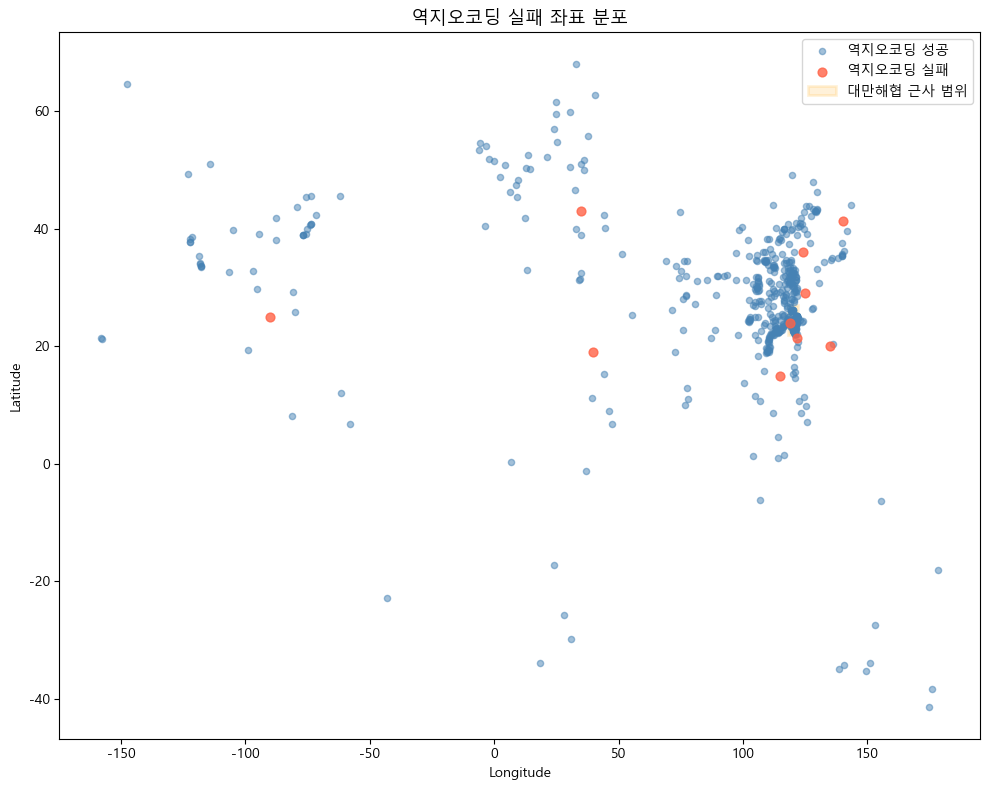

In [ ]:
# 윈도우용 한글 폰트 및 마이너스 기호 깨짐 방지
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# ── 2. 실패 좌표의 지리적 위치 시각화 ───────────────────────────
# 대만해협 범위 (근사): 위도 22~27°N, 경도 118~122°E

STRAIT_LAT = (22, 27)
STRAIT_LON = (118, 122)

fig, ax = plt.subplots(figsize=(10, 8))

# 성공 좌표
ax.scatter(
    coords_success['ActionGeo_Long'], coords_success['ActionGeo_Lat'],
    c='steelblue', s=20, alpha=0.5, label='역지오코딩 성공', zorder=2
)

# 실패 좌표
ax.scatter(
    coords_failed['ActionGeo_Long'], coords_failed['ActionGeo_Lat'],
    c='tomato', s=40, alpha=0.8, label='역지오코딩 실패', zorder=3
)

# 대만해협 박스 표시
from matplotlib.patches import Rectangle
strait_box = Rectangle(
    (STRAIT_LON[0], STRAIT_LAT[0]),
    STRAIT_LON[1] - STRAIT_LON[0],
    STRAIT_LAT[1] - STRAIT_LAT[0],
    linewidth=2, edgecolor='orange', facecolor='orange', alpha=0.15,
    label='대만해협 근사 범위', zorder=1
)
ax.add_patch(strait_box)

ax.set_title('역지오코딩 실패 좌표 분포', fontsize=13)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 3. 실패 좌표 중 대만해협 내부 비율 ──────────────────────────
in_strait = coords_failed[
    coords_failed['ActionGeo_Lat'].between(*STRAIT_LAT) &
    coords_failed['ActionGeo_Long'].between(*STRAIT_LON)
]

print(f"\n실패 좌표 중 대만해협 내부 : {len(in_strait):,}개 ({len(in_strait)/len(coords_failed)*100:.1f}%)")
print(f"실패 좌표 중 해협 외부     : {len(coords_failed) - len(in_strait):,}개")
print(f"\n[해협 외부 실패 좌표 - 해상 외 다른 원인 가능성]")
display(coords_failed[~coords_failed.index.isin(in_strait.index)][
    ['ActionGeo_Lat', 'ActionGeo_Long', 'event_count']
])


실패 좌표 중 대만해협 내부 : 1개 (10.0%)
실패 좌표 중 해협 외부     : 9개

[해협 외부 실패 좌표 - 해상 외 다른 원인 가능성]


,ActionGeo_Lat,ActionGeo_Long,event_count
40,15.00,115.00,79
51,19.00,39.50,1
63,20.00,135.00,6
75,21.42,121.50,99
252,25.00,-90.00,4
331,29.00,125.00,47
473,36.00,124.00,7
527,41.33,140.33,1
537,43.00,35.00,1


In [ ]:
# ── 명백한 오류 좌표 제거 ────────────────────────────────────────
# 양안 관심 구역 범위 밖 좌표 필터링
# 위도: 15~45°N, 경도: 100~145°E 로 관심 구역 한정

LAT_RANGE = (15, 45)
LON_RANGE = (100, 145)

coords_clean = coords[
    coords['ActionGeo_Lat'].between(*LAT_RANGE) &
    coords['ActionGeo_Long'].between(*LON_RANGE)
].copy()

removed = coords[
    ~(coords['ActionGeo_Lat'].between(*LAT_RANGE) &
      coords['ActionGeo_Long'].between(*LON_RANGE))
]

print(f"제거된 오류 좌표: {len(removed)}개")
print(removed[['ActionGeo_Lat', 'ActionGeo_Long', 'event_count']])
print(f"\n정제 후 좌표 수: {len(coords_clean):,}")

제거된 오류 좌표: 154개
     ActionGeo_Lat  ActionGeo_Long  event_count
0           -41.30          174.78            4
1           -38.33          176.00            1
2           -35.28          149.22           10
3           -34.93          138.60            2
4           -34.23          140.57            2
..             ...             ...          ...
581          59.89           30.26            1
582          61.48           24.70            2
583          62.71           40.29            2
584          64.56         -147.78            1
585          67.94           32.87            1

[154 rows x 3 columns]

정제 후 좌표 수: 432


In [ ]:
# ── country / state / city 각각 분포 ────────────────────────────
for level, col in [('Country', 'country'), ('State', 'state'), ('City', 'city')]:
    print("=" * 50)
    print(f"[{level} 분포]")
    vc = coords[col].value_counts(dropna=False)
    print(f"고유 값 수: {vc.shape[0]}")
    print(vc.to_string())
    print()

[Country 분포]
고유 값 수: 61
country
China                      267
Taiwan                     140
United States               31
Japan                       20
India                       16
Philippines                 12
None                        10
Canada                       6
Vietnam                      6
Australia                    5
Russia                       5
United Kingdom               4
Ukraine                      4
Indonesia                    3
South Africa                 3
Palestinian Territories      2
Pakistan                     2
Turkey                       2
Germany                      2
Switzerland                  2
Italy                        2
Czechia                      2
New Zealand                  2
Singapore                    1
São Tomé and Príncipe        1
Somalia                      1
Brunei                       1
Fiji                         1
Brazil                       1
Mexico                       1
Grenada                      1
Thailan

In [ ]:
# ── None 좌표 위치 확인 ──────────────────────────────────────────
# None = country 파싱 실패. 해상일 수도, 중국/대만 경계일 수도 있음

coords_none = coords[coords['country'].isna()][
    ['ActionGeo_Lat', 'ActionGeo_Long', 'event_count', 'place_name']
]
print(coords_none.to_string())

     ActionGeo_Lat  ActionGeo_Long  event_count place_name
40           15.00          115.00           79       None
51           19.00           39.50            1       None
63           20.00          135.00            6       None
75           21.42          121.50           99       None
184          24.00          119.00          722       None
252          25.00          -90.00            4       None
331          29.00          125.00           47       None
473          36.00          124.00            7       None
527          41.33          140.33            1       None
537          43.00           35.00            1       None


In [ ]:
# ── 명백한 오류 좌표 직접 제거 ───────────────────────────────────
error_coords = [
    (20.00, 135.00),  # 서태평양
    (41.33, 140.33),  # 일본 혼슈 북부
    (25.00, -90.00),  # 멕시코만
    (19.00,  39.50),  # 홍해
    (43.00,  35.00),  # 흑해
]

error_index = coords[
    coords[['ActionGeo_Lat', 'ActionGeo_Long']]
    .apply(tuple, axis=1)
    .isin(error_coords)
].index

coords_clean = coords.drop(index=error_index).copy()

print(f"제거된 오류 좌표 : {len(error_index)}개")
print(f"최종 좌표 수     : {len(coords_clean):,}")
print(f"\n[country 분포]")
print(coords_clean['country'].value_counts(dropna=False))

제거된 오류 좌표 : 5개
최종 좌표 수     : 581

[country 분포]
country
China            267
Taiwan           140
United States     31
Japan             20
India             16
                ... 
Ireland            1
Lithuania          1
Latvia             1
Estonia            1
Finland            1
Name: count, Length: 61, dtype: int64


In [ ]:
# ── China + Taiwan + 인근 해상(None) 좌표만 필터링 ───────────────
coords_clean = coords_clean[
    coords_clean['country'].isin(['China', 'Taiwan']) |
    coords_clean['country'].isna()
].copy()

print(f"최종 좌표 수: {len(coords_clean):,}")
print(f"\n[country 분포]")
print(coords_clean['country'].value_counts(dropna=False))

최종 좌표 수: 412

[country 분포]
country
China     267
Taiwan    140
None        5
Name: count, dtype: int64


In [ ]:
# ── 1. coords_clean을 원본 df에 조인 ─────────────────────────────
# coords_clean에는 좌표별 place 정보가 있고
# df에는 이벤트별 상세 정보가 있으므로 조인 필요

df_clean = df.merge(
    coords_clean[['ActionGeo_Lat', 'ActionGeo_Long', 
                  'country', 'state', 'city']],
    on=['ActionGeo_Lat', 'ActionGeo_Long'],
    how='inner'
)

print(f"정제 후 이벤트 수: {len(df_clean):,}")
print(f"정제 전 이벤트 수: {len(df):,}")

정제 후 이벤트 수: 10,958
정제 전 이벤트 수: 11,901


In [ ]:
# ── 2. 행정구역 3단계 분포 확인 ──────────────────────────────────
for level, col in [('Country', 'country'), ('State', 'state'), ('City', 'city')]:
    print("=" * 50)
    print(f"[{level} 분포]")
    vc = df_clean[col].value_counts(dropna=False)
    print(f"고유 값 수: {vc.shape[0]}")
    print(vc.to_string())
    print()

[Country 분포]
고유 값 수: 3
country
China     5776
Taiwan    4228
None       954

[State 분포]
고유 값 수: 30
state
                  8185
None               954
Guangdong          577
Fujian             205
Liaoning           159
Shanghai           155
Jiangsu            115
Zhejiang            70
Shaanxi             68
Sichuan             54
Hubei               49
Jilin               49
Jiangxi             43
Anhui               41
Guizhou             40
Henan               39
Hunan               35
Hainan              23
Guangxi             16
Gansu               14
Yunnan              14
Tibet               12
Shandong            12
Hebei                7
Inner Mongolia       7
Shanxi               4
Chongqing            3
Heilongjiang         3
Qinghai              3
Tianjin              2

[City 분포]
고유 값 수: 287
city
Xicheng District                             3901
Taipei                                       2851
None                                          954
Puli Township              

In [ ]:
# ── state 공백 및 None 실제 값 확인 ─────────────────────────────
print("[state 값 유형 확인]")
print(df_clean['state'].isna().sum(), "← NaN")
print((df_clean['state'] == '').sum(), "← 빈 문자열")
print((df_clean['state'] == ' ').sum(), "← 공백")

print("\n[state 공백/None인 행의 country 분포]")
mask = df_clean['state'].isna() | (df_clean['state'].str.strip() == '')
print(df_clean[mask]['country'].value_counts(dropna=False))

print("\n[state 공백/None인 행의 좌표 샘플]")
display(df_clean[mask][['ActionGeo_Lat', 'ActionGeo_Long', 
                         'country', 'state', 'city']].drop_duplicates().head(10))

[state 값 유형 확인]
954 ← NaN
8185 ← 빈 문자열
0 ← 공백

[state 공백/None인 행의 country 분포]
country
Taiwan    4228
China     3957
None       954
Name: count, dtype: int64

[state 공백/None인 행의 좌표 샘플]


,ActionGeo_Lat,ActionGeo_Long,country,state,city
0,39.93,116.39,China,,Xicheng District
2,25.05,121.53,Taiwan,,Taipei
5,39.90,116.39,China,,Dongcheng District
14,24.44,118.32,Taiwan,,Jincheng Township
15,24.00,121.00,Taiwan,,Puli Township
29,24.00,119.00,None,None,None
33,25.04,121.58,Taiwan,,Taipei
52,25.02,121.17,Taiwan,,Taoyuan City
79,23.50,119.50,Taiwan,,
81,22.88,121.05,Taiwan,,Yanping


In [ ]:
# ── city 분포 확인 ───────────────────────────────────────────────
print("[City 분포]")
vc_city = df_clean['city'].value_counts(dropna=False)
print(f"고유 값 수: {vc_city.shape[0]}")
print(vc_city.to_string())

[City 분포]
고유 값 수: 287
city
Xicheng District                             3901
Taipei                                       2851
None                                          954
Puli Township                                 387
Yingde City                                   381
Jincheng Township                             344
Taoyuan City                                  167
Shanghai                                      145
Dong'anshan Subdistrict                       104
                                               99
Zhanjiang City                                 63
Magong City                                    60
Xiamen                                         58
Xuyi County                                    52
Dongcheng District                             52
Hualien City                                   41
Qiaokou District                               41
Xinpi                                          41
Kaohsiung                                      41
Longxi                 

In [ ]:
# ── 1. city명 빈 문자열 확인 ─────────────────────────────────────
print("[city 값 유형]")
print(df_clean['city'].isna().sum(), "← NaN")
print((df_clean['city'] == '').sum(), "← 빈 문자열")

# ── 2. city 빈 문자열인 행 확인 ──────────────────────────────────
mask_empty_city = df_clean['city'].isna() | (df_clean['city'] == '')
print(f"\n[city 없는 행: {mask_empty_city.sum()}건]")
print(df_clean[mask_empty_city][
    ['ActionGeo_Lat', 'ActionGeo_Long', 'country', 'state', 'city']
].drop_duplicates().to_string())

[city 값 유형]
954 ← NaN
99 ← 빈 문자열

[city 없는 행: 1053건]
      ActionGeo_Lat  ActionGeo_Long country     state  city
29            24.00          119.00    None      None  None
79            23.50          119.50  Taiwan                
146           29.00          125.00    None      None  None
266           26.54          117.84   China    Fujian      
293           21.42          121.50    None      None  None
467           23.71          121.55  Taiwan                
494           15.00          115.00    None      None  None
1013          24.51          117.66   China    Fujian      
1106          24.91          118.59   China    Fujian      
1204          39.74           98.52   China     Gansu      
1480          36.00          124.00    None      None  None
3258          31.79          121.14   China  Shanghai      
4030          32.94          111.03   China     Hubei      
5418          28.59          112.33   China     Hunan      
7232          22.26          120.65  Taiwan    

In [ ]:
# ── city 없는 육상 좌표: state로 대체 ───────────────────────────
df_clean['city_filled'] = df_clean['city'].copy()

# 빈 문자열 → NaN 통일
df_clean['city_filled'] = df_clean['city_filled'].replace('', np.nan)

# city 없고 state 있는 경우 → state로 대체
mask = df_clean['city_filled'].isna() & df_clean['state'].notna() & (df_clean['state'] != '')
df_clean.loc[mask, 'city_filled'] = df_clean.loc[mask, 'state']

print(f"state로 대체된 행: {mask.sum()}건")
print(f"\n[city_filled 결측 잔여]")
print(df_clean['city_filled'].isna().sum(), "← 해상 좌표(None country) + 완전 미파싱")
print(f"\n[city_filled 분포 상위 20]")
print(df_clean['city_filled'].value_counts(dropna=False).head(20).to_string())

state로 대체된 행: 92건

[city_filled 결측 잔여]
961 ← 해상 좌표(None country) + 완전 미파싱

[city_filled 분포 상위 20]
city_filled
Xicheng District           3901
Taipei                     2851
None                        954
Puli Township               387
Yingde City                 381
Jincheng Township           344
Taoyuan City                167
Shanghai                    151
Dong'anshan Subdistrict     104
Fujian                       77
Zhanjiang City               63
Magong City                  60
Xiamen                       58
Xuyi County                  52
Dongcheng District           52
Qiaokou District             41
Kaohsiung                    41
Xinpi                        41
Hualien City                 41
Taichung                     28


In [ ]:
# ── District/Subdistrict/Township/County 단위 확인 ───────────────
keywords = ['District', 'Subdistrict', 'Township', 'County']

pattern = '|'.join(keywords)
mask_sub = df_clean['city_filled'].str.contains(pattern, na=False)

print(f"하위 행정구역 단위 포함 행: {mask_sub.sum()}건")
print(f"\n[해당 city_filled 값 분포]")
print(df_clean[mask_sub]['city_filled'].value_counts().to_string())

하위 행정구역 단위 포함 행: 5303건

[해당 city_filled 값 분포]
city_filled
Xicheng District                             3901
Puli Township                                 387
Jincheng Township                             344
Dong'anshan Subdistrict                       104
Dongcheng District                             52
Xuyi County                                    52
Qiaokou District                               41
Qian County                                    21
Anyue County                                   20
Jianghua Yao Autonomous County                 18
Xuanwu District                                17
Yuexiu District                                16
Xifeng County                                  16
Shenhe District                                15
Qingyang District                              14
Xinchang County                                12
Weining Yi Hui and Miao Autonomous County      11
Taijiang District                               9
Mengcheng County                          

In [ ]:
# ── Beijing District → Beijing 통합 ─────────────────────────────
# Nominatim 기준 Beijing 소속 District 목록
beijing_districts = [
    'Xicheng District', 'Dongcheng District', 'Xuanwu District',
    'Chongwen District', 'Haidian District', 'Chaoyang District',
    'Fengtai District', 'Shijingshan District', 'Mentougou District',
    'Fangshan District', 'Tongzhou District', 'Shunyi District',
    'Changping District', 'Daxing District', 'Huairou District',
    'Pinggu District', 'Miyun District', 'Yanqing District',
    "Dong'anshan Subdistrict"  # Heilongjiang 소속이나 확인 필요
]

df_clean['city_final'] = df_clean['city_filled'].copy()
df_clean.loc[df_clean['city_final'].isin(beijing_districts), 'city_final'] = 'Beijing'

# ── 결과 확인 ────────────────────────────────────────────────────
print("[통합 전후 비교]")
print(f"Xicheng District : {(df_clean['city_filled'] == 'Xicheng District').sum()}건 → Beijing으로 통합")
print(f"Beijing          : {(df_clean['city_final'] == 'Beijing').sum()}건")

print(f"\n[Dong'anshan Subdistrict 소속 확인]")
print(df_clean[df_clean['city_filled'] == "Dong'anshan Subdistrict"][
    ['ActionGeo_Lat', 'ActionGeo_Long', 'country', 'state']
].drop_duplicates())

[통합 전후 비교]
Xicheng District : 3901건 → Beijing으로 통합
Beijing          : 4075건

[Dong'anshan Subdistrict 소속 확인]
    ActionGeo_Lat  ActionGeo_Long country     state
60           41.0           123.0   China  Liaoning


In [ ]:
# ── Dong'anshan Subdistrict → Beijing 통합 목록에서 제거 ─────────
beijing_districts = [
    'Xicheng District', 'Dongcheng District', 'Xuanwu District',
    'Chongwen District', 'Haidian District', 'Chaoyang District',
    'Fengtai District', 'Shijingshan District', 'Mentougou District',
    'Fangshan District', 'Tongzhou District', 'Shunyi District',
    'Changping District', 'Daxing District', 'Huairou District',
    'Pinggu District', 'Miyun District', 'Yanqing District'
    # Dong'anshan Subdistrict 제외
]

df_clean['city_final'] = df_clean['city_filled'].copy()
df_clean.loc[df_clean['city_final'].isin(beijing_districts), 'city_final'] = 'Beijing'

# ── Dong'anshan Subdistrict → Fushun (좌표 41.0, 123.0 기준) ─────
df_clean.loc[df_clean['city_final'] == "Dong'anshan Subdistrict", 'city_final'] = 'Fushun'

# ── 결과 확인 ────────────────────────────────────────────────────
print("[city_final 상위 20]")
print(df_clean['city_final'].value_counts(dropna=False).head(20).to_string())

[city_final 상위 20]
city_final
Beijing              3971
Taipei               2851
None                  954
Puli Township         387
Yingde City           381
Jincheng Township     344
Taoyuan City          167
Shanghai              151
Fushun                104
Fujian                 77
Zhanjiang City         63
Magong City            60
Xiamen                 58
Xuyi County            52
Xinpi                  41
Hualien City           41
Qiaokou District       41
Kaohsiung              41
Longxi                 28
Taichung               28


In [ ]:
# ── 행정구역 단위 집계 ───────────────────────────────────────────
geo_agg = df_clean.groupby(['country', 'city_final']).agg(
    event_count    = ('EventCode', 'count'),        # 이벤트 빈도
    total_mentions = ('NumMentions', 'sum'),         # 언론 주목도
    avg_tone       = ('AvgTone', 'mean'),            # 평균 적대도
    latest_event   = ('SQLDATE', 'max'),             # 최신 이벤트
    unique_codes   = ('EventCode', 'nunique'),       # 이벤트 유형 다양성
    # 대표 좌표: 중앙값 기준
    rep_lat        = ('ActionGeo_Lat', 'median'),
    rep_lon        = ('ActionGeo_Long', 'median'),
).reset_index()

print(f"행정구역 수: {len(geo_agg)}개")
print(f"\n[집계 결과 상위 20 - 이벤트 빈도 기준]")
display(geo_agg.nlargest(20, 'event_count')[
    ['country', 'city_final', 'event_count', 
     'total_mentions', 'avg_tone', 'latest_event', 
     'rep_lat', 'rep_lon']
])

행정구역 수: 288개

[집계 결과 상위 20 - 이벤트 빈도 기준]


,country,city_final,event_count,total_mentions,avg_tone,latest_event,rep_lat,rep_lon
8,China,Beijing,3971,70061,-2.703829,2026-04-30,39.93,116.39
270,Taiwan,Taipei,2851,34934,-2.320932,2026-05-11,25.05,121.53
262,Taiwan,Puli Township,387,2888,-2.344338,2026-02-26,24.00,121.00
205,China,Yingde City,381,3348,-2.956425,2026-05-04,24.11,113.00
246,Taiwan,Jincheng Township,344,4184,-3.261354,2026-01-29,24.44,118.32
271,Taiwan,Taoyuan City,167,1414,-2.499152,2026-03-12,25.03,121.28
146,China,Shanghai,151,1345,-1.312011,2026-01-18,31.22,121.46
40,China,Fushun,104,745,-2.705174,2026-04-23,41.00,123.00
39,China,Fujian,77,832,-2.887350,2026-05-10,26.54,117.84
216,China,Zhanjiang City,63,341,-2.417924,2025-12-31,20.68,109.95


In [ ]:
# ── 이상치 후보 구역 SOURCEURL + 시계열 확인 ────────────────────
suspect_cities = ['Yingde City', 'Puli Township']

for city in suspect_cities:
    subset = df_clean[df_clean['city_final'] == city]
    
    print("=" * 60)
    print(f"[{city}] 총 {len(subset)}건")
    
    # 시계열 분포
    print(f"\n[월별 이벤트 분포]")
    print(subset.set_index('SQLDATE').resample('ME')['EventCode']
          .count().to_string())
    
    # 출처 URL 샘플
    print(f"\n[SOURCEURL 샘플 5개]")
    print(subset['SOURCEURL'].dropna().head(5).to_string())
    print()

[Yingde City] 총 381건

[월별 이벤트 분포]
SQLDATE
2014-04-30     1
2014-05-31     0
2014-06-30     0
2014-07-31     0
2014-08-31     0
2014-09-30     0
2014-10-31     0
2014-11-30     0
2014-12-31     0
2015-01-31     0
2015-02-28     0
2015-03-31     0
2015-04-30     0
2015-05-31     0
2015-06-30     0
2015-07-31     0
2015-08-31     0
2015-09-30     7
2015-10-31     1
2015-11-30     0
2015-12-31     7
2016-01-31     0
2016-02-29     0
2016-03-31     0
2016-04-30     1
2016-05-31     0
2016-06-30     0
2016-07-31     0
2016-08-31     4
2016-09-30     0
2016-10-31     1
2016-11-30     0
2016-12-31     1
2017-01-31     0
2017-02-28     0
2017-03-31     2
2017-04-30     0
2017-05-31    11
2017-06-30     1
2017-07-31     2
2017-08-31     1
2017-09-30     0
2017-10-31     0
2017-11-30     0
2017-12-31     0
2018-01-31     0
2018-02-28     0
2018-03-31     1
2018-04-30     4
2018-05-31     1
2018-06-30    15
2018-07-31     0
2018-08-31     0
2018-09-30     0
2018-10-31     0
2018-11-30     2
2018-1

In [ ]:
# 출력되는 문자열의 최대 길이를 제한 없이(None) 설정
pd.set_option('display.max_colwidth', None)

# 기존 코드 실행
subset = df_clean[df_clean['city_final'] == 'Puli Township']
print(subset['SOURCEURL'].dropna().head(5).to_string())

15                                                               https://www.shorenewsnetwork.com/2022/08/28/u-s-warships-transit-taiwan/
105    https://www.wionews.com/world/taiwan-expressed-sincere-gratitude-to-united-states-for-maintaining-security-in-taiwan-strait-506568
114                              https://www.businessinsider.com/inside-china-amphibious-training-could-be-key-in-taiwan-invasion-2024-12
173                                                         https://eurasiantimes.com/china-taiwan-conflict-japan-scrambles-fighter-jets/
264                      https://www.bignewsnetwork.com/news/272648313/global-lawmakers-express-concern-over-china-threats-against-taiwan


In [ ]:
# ── Puli Township URL 샘플 확인 ──────────────────────────────────
subset = df_clean[df_clean['city_final'] == 'Yingde City']
print(subset['SOURCEURL'].dropna().head(5).to_string())

49                                                                               https://www.taipeitimes.com/News/taiwan/archives/2022/03/21/2003775171
67                 https://www.bignewsnetwork.com/news/272629729/chinese-people-liberation-army-navy-ship-spotted-near-taiwan-ahead-of-annual-war-games
91                                                                               https://www.taipeitimes.com/News/taiwan/archives/2026/04/13/2003855501
125    http://www.msn.com/en-us/news/world/taiwan-s-defense-ministry-says-dozens-of-chinese-military-aircraft-entered-air-space-near-island/ar-AA166Ysk
172                                        http://www.msn.com/en-us/news/world/taiwan-says-china-simulating-attack-on-main-island-in-drills/ar-AA10mIXz


In [ ]:
# ── 이상치 구역 제거 ─────────────────────────────────────────────
remove_cities = ['Yingde City', 'Puli Township']

geo_agg_clean = geo_agg[~geo_agg['city_final'].isin(remove_cities)].copy()
df_clean = df_clean[~df_clean['city_final'].isin(remove_cities)].copy()

print(f"제거 전 행정구역 수: {len(geo_agg)}개")
print(f"제거 후 행정구역 수: {len(geo_agg_clean)}개")
print(f"\n[이벤트 빈도 기준 상위 20]")
display(geo_agg_clean.nlargest(20, 'event_count')[
    ['country', 'city_final', 'event_count', 
     'total_mentions', 'avg_tone', 'latest_event',
     'rep_lat', 'rep_lon']
])

제거 전 행정구역 수: 288개
제거 후 행정구역 수: 286개

[이벤트 빈도 기준 상위 20]


,country,city_final,event_count,total_mentions,avg_tone,latest_event,rep_lat,rep_lon
8,China,Beijing,3971,70061,-2.703829,2026-04-30,39.93,116.39
270,Taiwan,Taipei,2851,34934,-2.320932,2026-05-11,25.05,121.53
246,Taiwan,Jincheng Township,344,4184,-3.261354,2026-01-29,24.44,118.32
271,Taiwan,Taoyuan City,167,1414,-2.499152,2026-03-12,25.03,121.28
146,China,Shanghai,151,1345,-1.312011,2026-01-18,31.22,121.46
40,China,Fushun,104,745,-2.705174,2026-04-23,41.00,123.00
39,China,Fujian,77,832,-2.887350,2026-05-10,26.54,117.84
216,China,Zhanjiang City,63,341,-2.417924,2025-12-31,20.68,109.95
255,Taiwan,Magong City,60,550,-2.566814,2026-04-07,23.57,119.57
184,China,Xiamen,58,525,-2.996541,2025-05-27,24.48,118.08


In [ ]:
# ── 좌표별 집계 ──────────────────────────────────────────────────
coord_agg = df_clean.groupby(['ActionGeo_Lat', 'ActionGeo_Long']).agg(
    event_count      = ('EventCode', 'count'),
    total_mentions   = ('NumMentions', 'sum'),
    goldstein_weight = ('GoldsteinScale', lambda x: abs(x).sum()),  # 절댓값 합계
    country          = ('country', 'first'),
    city_final       = ('city_final', 'first'),
).reset_index()

# ── 정규화 ───────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

features = ['event_count', 'total_mentions', 'goldstein_weight']
for col in features:
    coord_agg[f'score_{col}'] = scaler.fit_transform(coord_agg[[col]])

# ── 가중합 ───────────────────────────────────────────────────────
weights = {
    'score_event_count'     : 0.35,
    'score_total_mentions'  : 0.35,
    'score_goldstein_weight': 0.30,
}

coord_agg['priority_score'] = sum(
    coord_agg[col] * w for col, w in weights.items()
)

# ── 결과 확인 ────────────────────────────────────────────────────
print("[좌표별 Priority Score Top 20]")
display(coord_agg.nlargest(20, 'priority_score')[
    ['country', 'city_final', 'ActionGeo_Lat', 'ActionGeo_Long',
     'priority_score', 'score_event_count', 
     'score_total_mentions', 'score_goldstein_weight']
].reset_index(drop=True))

[좌표별 Priority Score Top 20]


,country,city_final,ActionGeo_Lat,ActionGeo_Long,priority_score,score_event_count,score_total_mentions,score_goldstein_weight
0,China,Beijing,39.93,116.39,1.000000,1.000000,1.000000,1.000000
1,Taiwan,Taipei,25.05,121.53,0.637952,0.714103,0.495212,0.715640
2,None,None,24.00,119.00,0.179232,0.184872,0.174532,0.178136
3,Taiwan,Jincheng Township,24.44,118.32,0.078802,0.086923,0.059709,0.091604
4,China,Shanghai,31.22,121.46,0.031681,0.036923,0.019022,0.040334
5,China,Fushun,41.00,123.00,0.020812,0.026410,0.010681,0.026101
6,None,None,21.42,121.50,0.020276,0.025128,0.012720,0.023430
7,Taiwan,Taoyuan City,25.03,121.28,0.019790,0.024103,0.012189,0.023628
8,None,None,15.00,115.00,0.015139,0.020000,0.006145,0.019960
9,Taiwan,Taoyuan City,25.02,121.17,0.013846,0.017179,0.007566,0.017283


In [ ]:
# ── EventCode별 분포 및 좌표 다양성 확인 ────────────────────────
print(df_clean.groupby('EventCode').agg(
    event_count  = ('EventCode', 'count'),
    unique_coords = ('ActionGeo_Lat', lambda x: 
                     x.astype(str).add('_').add(
                         df_clean.loc[x.index, 'ActionGeo_Long'].astype(str)
                     ).nunique()),
    top_city     = ('city_final', lambda x: x.value_counts().index[0])
).sort_index().to_string())

           event_count  unique_coords  top_city
EventCode                                      
150               2498            131   Beijing
151                499             35   Beijing
152                109             17   Beijing
153                  9              3  Shanghai
154                899             62   Beijing
190               3462            228   Beijing
191                110             20    Taipei
192                840             76   Beijing
193                592             75   Beijing
194                632             74   Beijing
195                489             48   Beijing
201                  2              2  Shanghai
202                 46             10   Beijing
203                  3              1    Taipei


In [ ]:
# ── ActionGeo_Type별 분포 및 top_city 확인 ───────────────────────
print(df_clean.groupby('ActionGeo_Type').agg(
    event_count   = ('EventCode', 'count'),
    unique_coords = ('ActionGeo_Lat', lambda x:
                     x.astype(str).add('_').add(
                         df_clean.loc[x.index, 'ActionGeo_Long'].astype(str)
                     ).nunique()),
    top_city      = ('city_final', lambda x: x.value_counts().index[0])
).to_string())

                event_count  unique_coords top_city
ActionGeo_Type                                     
4                      9874            385  Beijing
5                       316             25   Fushun


In [ ]:
# ── Type 5 필터링 ────────────────────────────────────────────────
df_type5 = df_clean[df_clean['ActionGeo_Type'] == 5].copy()

print(f"Type 5 이벤트 수 : {len(df_type5):,}")
print(f"고유 좌표 수     : {df_type5.groupby(['ActionGeo_Lat','ActionGeo_Long']).ngroups}")

# ── 좌표별 집계 ──────────────────────────────────────────────────
coord_agg_t5 = df_type5.groupby(['ActionGeo_Lat', 'ActionGeo_Long']).agg(
    event_count      = ('EventCode', 'count'),
    total_mentions   = ('NumMentions', 'sum'),
    goldstein_weight = ('GoldsteinScale', lambda x: abs(x).sum()),
    country          = ('country', 'first'),
    city_final       = ('city_final', 'first'),
).reset_index()

# ── 정규화 ───────────────────────────────────────────────────────
scaler = MinMaxScaler()
features = ['event_count', 'total_mentions', 'goldstein_weight']
for col in features:
    coord_agg_t5[f'score_{col}'] = scaler.fit_transform(coord_agg_t5[[col]])

# ── 가중합 ───────────────────────────────────────────────────────
weights = {
    'score_event_count'     : 0.35,
    'score_total_mentions'  : 0.35,
    'score_goldstein_weight': 0.30,
}

coord_agg_t5['priority_score'] = sum(
    coord_agg_t5[col] * w for col, w in weights.items()
)

# ── 결과 확인 ────────────────────────────────────────────────────
print("\n[Type 5 좌표별 Priority Score 전체]")
display(coord_agg_t5.sort_values('priority_score', ascending=False)[
    ['country', 'city_final', 'ActionGeo_Lat', 'ActionGeo_Long',
     'priority_score', 'score_event_count',
     'score_total_mentions', 'score_goldstein_weight',
     'event_count', 'total_mentions']
].reset_index(drop=True))

Type 5 이벤트 수 : 316
고유 좌표 수     : 25

[Type 5 좌표별 Priority Score 전체]


,country,city_final,ActionGeo_Lat,ActionGeo_Long,priority_score,score_event_count,score_total_mentions,score_goldstein_weight,event_count,total_mentions
0,China,Fushun,41.00,123.00,1.000000,1.000000,1.000000,1.000000,104,745
1,China,Fujian,26.54,117.84,0.655470,0.563107,0.843876,0.543420,59,629
2,Taiwan,Xinpi,22.50,120.61,0.496985,0.388350,0.679677,0.410586,41,507
3,China,Yan'an,36.00,109.00,0.248328,0.233010,0.285330,0.223030,25,214
4,China,Yongkang,29.00,120.00,0.149420,0.165049,0.130552,0.153201,18,99
5,Taiwan,Magong City,23.57,119.61,0.076058,0.087379,0.067295,0.073075,10,52
6,China,Laibin,24.00,109.00,0.075087,0.058252,0.098250,0.067704,7,75
7,Taiwan,Jinhu Town,24.45,118.39,0.049328,0.048544,0.052490,0.046553,6,41
8,Taiwan,Wanrong,23.78,121.39,0.044781,0.048544,0.033647,0.053380,6,27
9,China,Sunan Yugur Autonomous County,38.00,102.00,0.043829,0.019417,0.088829,0.019808,3,68


In [ ]:
# ── 이상치 후보 구역 URL + 시계열 확인 ──────────────────────────
suspect_cities = ["Yan'an", 'Sunan Yugur Autonomous County', 'Suihua City']

for city in suspect_cities:
    subset = df_type5[df_type5['city_final'] == city]
    
    print("=" * 60)
    print(f"[{city}] 총 {len(subset)}건")
    
    print(f"\n[월별 이벤트 분포]")
    print(subset.set_index('SQLDATE').resample('ME')['EventCode']
          .count()[lambda x: x > 0].to_string())
    
    print(f"\n[SOURCEURL 전체]")
    print(subset['SOURCEURL'].dropna().to_string())
    print()

[Yan'an] 총 25건

[월별 이벤트 분포]
SQLDATE
2017-12-31    4
2020-10-31    3
2020-11-30    1
2021-02-28    1
2021-12-31    4
2022-01-31    4
2022-02-28    1
2022-03-31    1
2023-04-30    2
2024-09-30    2
2025-04-30    2

[SOURCEURL 전체]
63                                                         https://www.newzealandstar.com/news/272090099/chinese-plane-enters-taiwan-air-defence-identification-zone
596            https://www.business-standard.com/article/international/3-chinese-warplanes-enter-taiwan-air-defence-zone-23rd-intrusion-of-month-121123100517_1.html
962                                                                                                                    https://www.taiwannews.com.tw/en/news/4385938
1196                                                                https://www.beijingbulletin.com/news/272108644/2-chinese-warplanes-enter-taiwan-air-defence-zone
1262                      https://www.janes.com/defence-news/china-deploys-aircraft-in-taiwans-adiz-but-no-incre

In [ ]:
# ── 이상치 제거 ──────────────────────────────────────────────────
remove_cities_t5 = ['Sunan Yugur Autonomous County', 'Suihua City']

df_type5 = df_type5[~df_type5['city_final'].isin(remove_cities_t5)].copy()
coord_agg_t5 = coord_agg_t5[~coord_agg_t5['city_final'].isin(remove_cities_t5)].copy()

print(f"제거 후 이벤트 수 : {len(df_type5):,}")
print(f"제거 후 좌표 수   : {len(coord_agg_t5):,}")

제거 후 이벤트 수 : 312
제거 후 좌표 수   : 23


In [ ]:
# ── Priority Score 재산출 ────────────────────────────────────────
scaler = MinMaxScaler()
features = ['event_count', 'total_mentions', 'goldstein_weight']
for col in features:
    coord_agg_t5[f'score_{col}'] = scaler.fit_transform(coord_agg_t5[[col]])

weights = {
    'score_event_count'     : 0.35,
    'score_total_mentions'  : 0.35,
    'score_goldstein_weight': 0.30,
}

coord_agg_t5['priority_score'] = sum(
    coord_agg_t5[col] * w for col, w in weights.items()
)

print("[최종 Priority Score 전체]")
display(coord_agg_t5.sort_values('priority_score', ascending=False)[
    ['country', 'city_final', 'ActionGeo_Lat', 'ActionGeo_Long',
     'priority_score', 'score_event_count',
     'score_total_mentions', 'score_goldstein_weight',
     'event_count', 'total_mentions']
].reset_index(drop=True))

[최종 Priority Score 전체]


,country,city_final,ActionGeo_Lat,ActionGeo_Long,priority_score,score_event_count,score_total_mentions,score_goldstein_weight,event_count,total_mentions
0,China,Fushun,41.00,123.00,1.000000,1.000000,1.000000,1.000000,104,745
1,China,Fujian,26.54,117.84,0.655470,0.563107,0.843876,0.543420,59,629
2,Taiwan,Xinpi,22.50,120.61,0.496985,0.388350,0.679677,0.410586,41,507
3,China,Yan'an,36.00,109.00,0.248328,0.233010,0.285330,0.223030,25,214
4,China,Yongkang,29.00,120.00,0.149420,0.165049,0.130552,0.153201,18,99
5,Taiwan,Magong City,23.57,119.61,0.076058,0.087379,0.067295,0.073075,10,52
6,China,Laibin,24.00,109.00,0.075087,0.058252,0.098250,0.067704,7,75
7,Taiwan,Jinhu Town,24.45,118.39,0.049328,0.048544,0.052490,0.046553,6,41
8,Taiwan,Wanrong,23.78,121.39,0.044781,0.048544,0.033647,0.053380,6,27
9,China,Sonid Left Banner,44.00,112.00,0.036145,0.038835,0.033647,0.035922,5,27


- 1 Fushun (중국)랴오닝성 군사기지 밀집 지역
- 2 Fujian (중국)대만해협 맞은편 최전선 기지
- 3 Xinpi (대만)대만 서해안
- 4 Yan'an (중국)중국 군용기 ADIZ 침입 관련 내륙 기지
- 5 Magong City (대만)펑후제도 해군·공군 전략 거점
- 7 Jinhu Town (대만)금문도 인근

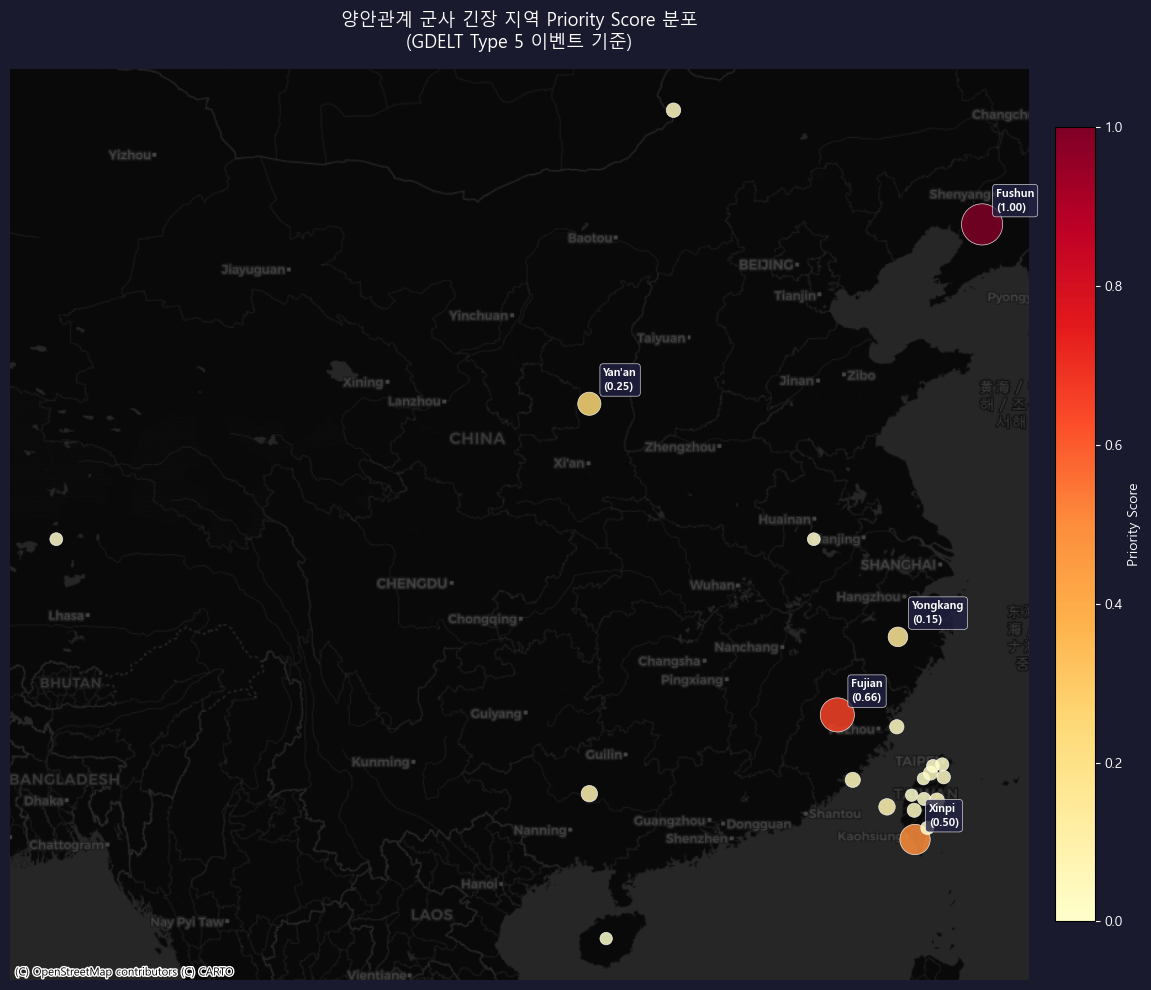

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

# ── GeoDataFrame 변환 ────────────────────────────────────────────
gdf = gpd.GeoDataFrame(
    coord_agg_t5,
    geometry=[Point(xy) for xy in zip(
        coord_agg_t5['ActionGeo_Long'], 
        coord_agg_t5['ActionGeo_Lat']
    )],
    crs='EPSG:4326'
).to_crs(epsg=3857)  # Web Mercator로 변환 (contextily 호환)

fig, ax = plt.subplots(figsize=(14, 10))

# ── 컬러 설정 ────────────────────────────────────────────────────
norm = Normalize(vmin=0, vmax=1)
cmap = plt.cm.YlOrRd

colors = [cmap(norm(s)) for s in gdf['priority_score']]
sizes  = 80 + gdf['priority_score'] * 800

# ── 좌표 플롯 ────────────────────────────────────────────────────
gdf.plot(
    ax=ax, color=colors, markersize=sizes,
    alpha=0.85, edgecolor='white', linewidth=0.5, zorder=3
)

# ── 상위 5개 라벨 ────────────────────────────────────────────────
top5 = gdf.sort_values('priority_score', ascending=False).head(5)
for _, row in top5.iterrows():
    ax.annotate(
        f"{row['city_final']}\n({row['priority_score']:.2f})",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(10, 10), textcoords='offset points',
        color='white', fontsize=8, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='#222244', alpha=0.8, edgecolor='white', linewidth=0.5)
    )

# ── 지도 배경 추가 ───────────────────────────────────────────────
ctx.add_basemap(
    ax, 
    source=ctx.providers.CartoDB.DarkMatter,
    zoom=5
)

# ── 컬러바 ───────────────────────────────────────────────────────
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Priority Score', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

# ── 축 설정 ──────────────────────────────────────────────────────
ax.set_axis_off()
fig.patch.set_facecolor('#1a1a2e')
ax.set_title(
    '양안관계 군사 긴장 지역 Priority Score 분포\n(GDELT Type 5 이벤트 기준)',
    color='white', fontsize=13, pad=15
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# ── 대만 군사시설 좌표 입력 ──────────────────────────────────────
military_tw = pd.DataFrame([
    # 육군
    {'unit': '육군사령부', 'branch': '육군', 'lat': 24.864, 'lon': 121.238},
    {'unit': '제6군단사령부', 'branch': '육군', 'lat': 24.87, 'lon': 121.24},
    {'unit': '제21포병지휘부', 'branch': '육군', 'lat': 24.912, 'lon': 121.245},
    {'unit': '관두지구지휘부', 'branch': '육군', 'lat': 25.131, 'lon': 121.462},
    {'unit': '란양지구지휘부', 'branch': '육군', 'lat': 24.673, 'lon': 121.701},
    {'unit': '제269기계화보병여단', 'branch': '육군', 'lat': 24.845, 'lon': 121.143},
    {'unit': '제542기갑여단', 'branch': '육군', 'lat': 24.908, 'lon': 121.05},
    {'unit': '제584기갑여단', 'branch': '육군', 'lat': 24.898, 'lon': 121.034},
    {'unit': '제153보병여단', 'branch': '육군', 'lat': 24.751, 'lon': 121.739},
    {'unit': '제206보병여단', 'branch': '육군', 'lat': 24.795, 'lon': 121.155},
    {'unit': '제8군단사령부', 'branch': '육군', 'lat': 22.845, 'lon': 120.485},
    {'unit': '제43포병지휘부', 'branch': '육군', 'lat': 22.684, 'lon': 120.428},
    {'unit': '제333기계화보병여단', 'branch': '육군', 'lat': 22.595, 'lon': 120.582},
    {'unit': '제564기갑여단', 'branch': '육군', 'lat': 22.868, 'lon': 120.316},
    {'unit': '제203보병여단', 'branch': '육군', 'lat': 23.195, 'lon': 120.334},
    {'unit': '제10군단사령부', 'branch': '육군', 'lat': 24.232, 'lon': 120.812},
    {'unit': '제58포병지휘부', 'branch': '육군', 'lat': 24.265, 'lon': 120.655},
    {'unit': '제234기계화보병여단', 'branch': '육군', 'lat': 24.088, 'lon': 120.702},
    {'unit': '제586기갑여단', 'branch': '육군', 'lat': 24.298, 'lon': 120.718},
    {'unit': '제104보병여단', 'branch': '육군', 'lat': 24.116, 'lon': 120.603},
    {'unit': '제257보병여단', 'branch': '육군', 'lat': 23.442, 'lon': 120.505},
    {'unit': '환동방위지휘부', 'branch': '육군', 'lat': 24.135, 'lon': 121.615},
    {'unit': '타이동지구지휘부', 'branch': '육군', 'lat': 22.792, 'lon': 121.102},
    {'unit': '평후방위지휘부', 'branch': '육군', 'lat': 23.571, 'lon': 119.574},
    {'unit': '진먼방위지휘부', 'branch': '육군', 'lat': 24.448, 'lon': 118.388},
    {'unit': '마주방위지휘부', 'branch': '육군', 'lat': 26.155, 'lon': 119.936},
    {'unit': '동연방위지휘부', 'branch': '육군', 'lat': 26.365, 'lon': 120.485},
    {'unit': '항공특전지휘부', 'branch': '육군', 'lat': 24.872, 'lon': 121.235},
    {'unit': '제601항공여단', 'branch': '육군', 'lat': 24.836, 'lon': 121.233},
    {'unit': '제602항공여단', 'branch': '육군', 'lat': 24.225, 'lon': 120.801},
    {'unit': '특종작전지휘부', 'branch': '육군', 'lat': 24.872, 'lon': 121.235},
    # 해군
    {'unit': '해군사령부', 'branch': '해군', 'lat': 25.085, 'lon': 121.538},
    {'unit': '해군합대지휘부', 'branch': '해군', 'lat': 22.695, 'lon': 120.285},
    {'unit': '해군보수지휘부', 'branch': '해군', 'lat': 22.692, 'lon': 120.29},
    {'unit': '해군교육훈련기준발전지휘부', 'branch': '해군', 'lat': 22.705, 'lon': 120.295},
    {'unit': '제124함대(가오슝)', 'branch': '해군', 'lat': 22.695, 'lon': 120.285},
    {'unit': '제131함대(지룽)', 'branch': '해군', 'lat': 25.138, 'lon': 121.748},
    {'unit': '제146함대(마공)', 'branch': '해군', 'lat': 23.555, 'lon': 119.565},
    {'unit': '제151함대(가오슝)', 'branch': '해군', 'lat': 22.69, 'lon': 120.288},
    {'unit': '제168함대(쑤아오)', 'branch': '해군', 'lat': 24.598, 'lon': 121.872},
    {'unit': '제192함대(가오슝)', 'branch': '해군', 'lat': 22.691, 'lon': 120.287},
    {'unit': '제256전대(가오슝)', 'branch': '해군', 'lat': 22.693, 'lon': 120.284},
    {'unit': '제261전대(쑤아오)', 'branch': '해군', 'lat': 24.595, 'lon': 121.875},
    {'unit': '유도탄대대(하이펑)', 'branch': '해군', 'lat': 25.245, 'lon': 121.505},
    {'unit': '해상감시지휘부', 'branch': '해군', 'lat': 25.175, 'lon': 121.442},
    {'unit': '무인기대대', 'branch': '해군', 'lat': 22.675, 'lon': 120.505},
    {'unit': '진먼기지지휘부', 'branch': '해군', 'lat': 24.415, 'lon': 118.299},
    {'unit': '마쭈기지지휘부', 'branch': '해군', 'lat': 26.158, 'lon': 119.925},
    {'unit': '둥인기지지휘부', 'branch': '해군', 'lat': 26.368, 'lon': 120.482},
    {'unit': '해군육전대지휘부', 'branch': '해군', 'lat': 22.702, 'lon': 120.298},
    {'unit': '육전 제66여단', 'branch': '해군', 'lat': 24.398, 'lon': 121.378},
    {'unit': '육전 제99여단', 'branch': '해군', 'lat': 22.495, 'lon': 120.395},
    {'unit': '들륙전자대대', 'branch': '해군', 'lat': 22.69, 'lon': 120.295},
    {'unit': '우추수비대대', 'branch': '해군', 'lat': 24.975, 'lon': 119.462},
    {'unit': '양서정수대대', 'branch': '해군', 'lat': 22.698, 'lon': 120.282},
    {'unit': '3군연합작전훈련기지지휘부', 'branch': '해군', 'lat': 22.012, 'lon': 120.749},
    # 공군
    {'unit': '공군사령부', 'branch': '공군', 'lat': 25.085, 'lon': 121.538},
    {'unit': '공군작전지휘부', 'branch': '공군', 'lat': 25.012, 'lon': 121.543},
    {'unit': '공군보수지휘부', 'branch': '공군', 'lat': 22.692, 'lon': 120.29},
    {'unit': '공군교육훈련기준발전지휘부', 'branch': '공군', 'lat': 24.232, 'lon': 120.812},
    {'unit': '제1전술전투기연대(타이난)', 'branch': '공군', 'lat': 22.95, 'lon': 120.205},
    {'unit': '제2전술전투기연대(신주)', 'branch': '공군', 'lat': 24.818, 'lon': 120.939},
    {'unit': '제3전술전투기연대(타이중)', 'branch': '공군', 'lat': 24.262, 'lon': 120.619},
    {'unit': '제4전술전투기연대(자이)', 'branch': '공군', 'lat': 23.461, 'lon': 120.395},
    {'unit': '제5전술혼합연대(화롄)', 'branch': '공군', 'lat': 24.023, 'lon': 121.617},
    {'unit': '제6혼합연대(평둥)', 'branch': '공군', 'lat': 22.695, 'lon': 120.485},
    {'unit': '제7비행훈련연대(타이둥)', 'branch': '공군', 'lat': 22.793, 'lon': 121.181},
    {'unit': '쑹산기지지휘부(타이베이)', 'branch': '공군', 'lat': 25.068, 'lon': 121.552},
    {'unit': '공군방공기비반지휘부', 'branch': '공군', 'lat': 22.942, 'lon': 120.258},
    {'unit': '791방공여단', 'branch': '공군', 'lat': 25.05, 'lon': 121.5},
    {'unit': '792방공여단', 'branch': '공군', 'lat': 24.15, 'lon': 120.65},
    {'unit': '793방공여단', 'branch': '공군', 'lat': 22.6, 'lon': 120.3},
    {'unit': '794방공여단', 'branch': '공군', 'lat': 22.6, 'lon': 120.5},
    {'unit': '795방공여단', 'branch': '공군', 'lat': 24, 'lon': 121.6},
    {'unit': '전술관제연대', 'branch': '공군', 'lat': 25.012, 'lon': 121.543},
])

print(f"대만 군사시설 총 {len(military_tw)}개")

# ── 우리 데이터 좌표와 근접 매칭 (반경 0.1도 ≈ 11km) ────────────
THRESHOLD = 0.1

matches = []
for _, m in military_tw.iterrows():
    for _, c in coord_agg_t5.iterrows():
        dist = np.sqrt(
            (m['lat'] - c['ActionGeo_Lat'])**2 + 
            (m['lon'] - c['ActionGeo_Long'])**2
        )
        if dist <= THRESHOLD:
            matches.append({
                'unit'          : m['unit'],
                'branch'        : m['branch'],
                'mil_lat'       : m['lat'],
                'mil_lon'       : m['lon'],
                'gdelt_lat'     : c['ActionGeo_Lat'],
                'gdelt_lon'     : c['ActionGeo_Long'],
                'city_final'    : c['city_final'],
                'priority_score': c['priority_score'],
                'distance_deg'  : round(dist, 4)
            })

matches_df = pd.DataFrame(matches)

print(f"\n매칭된 군사시설 수 : {matches_df['unit'].nunique()}개")
print(f"매칭된 GDELT 좌표  : {matches_df['gdelt_lat'].nunique()}개")
print(f"\n[매칭 결과]")
display(matches_df.sort_values('priority_score', ascending=False))

대만 군사시설 총 75개

매칭된 군사시설 수 : 16개
매칭된 GDELT 좌표  : 7개

[매칭 결과]


,unit,branch,mil_lat,mil_lon,gdelt_lat,gdelt_lon,city_final,priority_score,distance_deg
3,제333기계화보병여단,육군,22.595,120.582,22.50,120.61,Xinpi,0.496985,0.0990
5,평후방위지휘부,육군,23.571,119.574,23.57,119.61,Magong City,0.076058,0.0360
11,제146함대(마공),해군,23.555,119.565,23.57,119.61,Magong City,0.076058,0.0474
6,진먼방위지휘부,육군,24.448,118.388,24.45,118.39,Jinhu Town,0.049328,0.0028
12,진먼기지지휘부,해군,24.415,118.299,24.45,118.39,Jinhu Town,0.049328,0.0975
13,마쭈기지지휘부,해군,26.158,119.925,26.16,119.96,Nangan,0.032848,0.0351
7,마주방위지휘부,육군,26.155,119.936,26.16,119.96,Nangan,0.032848,0.0245
4,제257보병여단,육군,23.442,120.505,23.46,120.58,Fanlu Township,0.028913,0.0771
15,전술관제연대,공군,25.012,121.543,24.95,121.58,New Taipei,0.012576,0.0722
14,공군작전지휘부,공군,25.012,121.543,24.95,121.58,New Taipei,0.012576,0.0722


In [ ]:
print(matches_df.sort_values('priority_score', ascending=False).to_string())

           unit branch  mil_lat  mil_lon  gdelt_lat  gdelt_lon      city_final  priority_score  distance_deg
3   제333기계화보병여단     육군   22.595  120.582      22.50     120.61           Xinpi        0.496985        0.0990
5       평후방위지휘부     육군   23.571  119.574      23.57     119.61     Magong City        0.076058        0.0360
11   제146함대(마공)     해군   23.555  119.565      23.57     119.61     Magong City        0.076058        0.0474
6       진먼방위지휘부     육군   24.448  118.388      24.45     118.39      Jinhu Town        0.049328        0.0028
12      진먼기지지휘부     해군   24.415  118.299      24.45     118.39      Jinhu Town        0.049328        0.0975
13      마쭈기지지휘부     해군   26.158  119.925      26.16     119.96          Nangan        0.032848        0.0351
7       마주방위지휘부     육군   26.155  119.936      26.16     119.96          Nangan        0.032848        0.0245
4      제257보병여단     육군   23.442  120.505      23.46     120.58  Fanlu Township        0.028913        0.0771
15       전술관제연대    

In [ ]:
# ── Fushun 이벤트 날짜 + URL 전체 ───────────────────────────────
fushun = df_type5[
    (df_type5['ActionGeo_Lat'] == 41.00) & 
    (df_type5['ActionGeo_Long'] == 123.00)
].copy()

print(f"[Fushun] 총 {len(fushun)}건")
print(f"\n[날짜 리스트]")
print(fushun['SQLDATE'].dt.date.value_counts().sort_index().to_string().head(10))
print(f"\n[SOURCEURL 전체]")
print(fushun[['SQLDATE', 'EventCode', 'SOURCEURL']].sort_values('SQLDATE').to_string().head(10))

[Fushun] 총 104건

[날짜 리스트]
SQLDATE
2014-03-23    2
2014-04-22    1
2016-07-19    5
2016-07-20    2
2016-07-24    1
2016-09-10    2
2016-12-16    4
2016-12-28    1
2017-01-08    2
2017-01-10    2
2017-01-11    3
2017-01-17    2
2017-03-20    2
2017-03-22    1
2018-03-24    1
2018-04-18    1
2018-04-19    2
2018-10-13    1
2018-10-17    2
2018-10-21    2
2019-04-27    1
2019-07-16    1
2019-07-29    2
2019-07-31    3
2020-04-08    1
2020-04-14    2
2020-04-15    1
2020-04-23    1
2020-05-27    1
2020-07-15    2
2020-07-16    2
2020-08-25    1
2020-09-01    1
2020-09-07    1
2020-09-19    1
2020-09-20    1
2021-03-07    1
2021-04-05    2
2021-04-06    1
2021-04-08    1
2021-04-11    2
2021-04-15    2
2021-04-16    2
2021-07-02    1
2021-09-20    1
2021-11-02    1
2021-12-12    1
2021-12-18    1
2022-05-03    3
2022-05-05    2
2022-05-14    2
2022-08-03    1
2022-08-06    3
2022-11-21    1
2022-12-30    1
2024-10-14    3
2024-10-15    2
2024-10-18    1
2024-10-22    3
2024-10-23    1
2025-0